In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=False)

# Custom Dataset
class OpinionDataset(Dataset):
    def __init__(self, texts, level1, level2, level3, tokenizer, max_len=128):
        self.texts = texts
        self.level1 = level1
        self.level2 = level2
        self.level3 = level3
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], truncation=True, padding='max_length',
                                  max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label1': torch.tensor(self.level1[idx], dtype=torch.long),
            'label2': torch.tensor(-1 if pd.isna(self.level2[idx]) else self.level2[idx], dtype=torch.long),
            'label3': torch.tensor(-1 if pd.isna(self.level3[idx]) else self.level3[idx], dtype=torch.long),
            'text': self.texts[idx]
        }

# Hierarchical Model
class HierarchicalBertweet(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("vinai/bertweet-base")
        self.dropout = nn.Dropout(0.3)
        self.classifier1 = nn.Linear(768, 3)
        self.classifier2 = nn.Linear(768, 3)
        self.classifier3 = nn.Linear(768, 4)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0]  # CLS token
        x = self.dropout(output)
        out1 = self.classifier1(x)
        out2 = self.classifier2(x)
        out3 = self.classifier3(x)
        return out1, out2, out3

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader

def train_and_evaluate(df, tokenizer, epochs=3, batch_size=16, folds=10):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    all_preds1, all_labels1 = [], []
    all_preds2, all_labels2 = [], []
    all_preds3, all_labels3 = [], []

    misclassified_data = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(df['text'], df['level1'])):
        print(f"\n====== Fold {fold+1} ======")
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        train_dataset = OpinionDataset(train_df['text'].tolist(), train_df['level1'].tolist(),
                                       train_df['level2'].tolist(), train_df['level3'].tolist(), tokenizer)
        val_dataset = OpinionDataset(val_df['text'].tolist(), val_df['level1'].tolist(),
                                     val_df['level2'].tolist(), val_df['level3'].tolist(), tokenizer)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        model = HierarchicalBertweet().cuda()
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
        loss_fn = nn.CrossEntropyLoss(ignore_index=-1)
        best_score = 0.0
        best_model_path = f"best_model_fold{fold+1}.pt"
        for epoch in range(epochs):
            model.train()
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
                input_ids = batch['input_ids'].cuda()
                attention_mask = batch['attention_mask'].cuda()
                label1 = batch['label1'].cuda()
                label2 = batch['label2'].cuda()
                label3 = batch['label3'].cuda()

                out1, out2, out3 = model(input_ids, attention_mask)
                loss1 = loss_fn(out1, label1)
                loss2 = loss_fn(out2, label2)
                loss3 = loss_fn(out3, label3)
                loss = loss1 + loss2 + loss3

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Evaluation after each epoch
            model.eval()
            val_true1, val_pred1 = [], []
            val_true2, val_pred2 = [], []
            val_true3, val_pred3 = [], []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].cuda()
                    attention_mask = batch['attention_mask'].cuda()
                    label1 = batch['label1']
                    label2 = batch['label2']
                    label3 = batch['label3']

                    out1, out2, out3 = model(input_ids, attention_mask)
                    pred1 = torch.argmax(out1, dim=1).cpu()
                    pred2 = torch.argmax(out2, dim=1).cpu()
                    pred3 = torch.argmax(out3, dim=1).cpu()

                    val_true1.extend(label1.tolist())
                    val_pred1.extend(pred1.tolist())

                    for i in range(len(label1)):
                        if label1[i] == 2:
                            val_true2.append(label2[i].item())
                            val_pred2.append(pred2[i].item())
                            if label2[i] == 0:
                                val_true3.append(label3[i].item())
                                val_pred3.append(pred3[i].item())

            lev1_acc = accuracy_score(val_true1, val_pred1)
            lev1_f1 = f1_score(val_true1, val_pred1, average='weighted')
            combined_score = lev1_acc + lev1_f1

            print(f"\n📊 Epoch {epoch+1} Evaluation:")
            print(f"  Level 1 Accuracy: {lev1_acc:.4f}, F1: {lev1_f1:.4f}, Score: {combined_score:.4f}")
            if val_true2:
                print(f"  Level 2 Accuracy: {accuracy_score(val_true2, val_pred2):.4f}, F1: {f1_score(val_true2, val_pred2, average='weighted'):.4f}")
            if val_true3:
                print(f"  Level 3 Accuracy: {accuracy_score(val_true3, val_pred3):.4f}, F1: {f1_score(val_true3, val_pred3, average='weighted'):.4f}")

            if combined_score > best_score:
                best_score = combined_score
                torch.save(model.state_dict(), best_model_path)
                print(f"💾 Best model saved at Epoch {epoch+1} with score = {combined_score:.4f}")

        # Load best model and evaluate
        model.load_state_dict(torch.load(best_model_path))
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].cuda()
                attention_mask = batch['attention_mask'].cuda()
                label1 = batch['label1']
                label2 = batch['label2']
                label3 = batch['label3']
                texts = batch['text']

                out1, out2, out3 = model(input_ids, attention_mask)
                pred1 = torch.argmax(out1, dim=1).cpu()
                pred2 = torch.argmax(out2, dim=1).cpu()
                pred3 = torch.argmax(out3, dim=1).cpu()

                for i in range(len(texts)):
                    all_preds1.append(pred1[i].item())
                    all_labels1.append(label1[i].item())

                    if label1[i] == 2:
                        all_preds2.append(pred2[i].item())
                        all_labels2.append(label2[i].item())

                        if label2[i] == 0:
                            all_preds3.append(pred3[i].item())
                            all_labels3.append(label3[i].item())

                            if label3[i].item() != pred3[i].item():
                                misclassified_data.append({
                                    "text": texts[i],
                                    "true_level1": label1[i].item(), "pred_level1": pred1[i].item(),
                                    "true_level2": label2[i].item(), "pred_level2": pred2[i].item(),
                                    "true_level3": label3[i].item(), "pred_level3": pred3[i].item()
                                })
                    elif label1[i].item() != pred1[i].item():
                        misclassified_data.append({
                            "text": texts[i],
                            "true_level1": label1[i].item(), "pred_level1": pred1[i].item()
                        })

    return (all_labels1, all_preds1,
            all_labels2, all_preds2,
            all_labels3, all_preds3,
            pd.DataFrame(misclassified_data),
            model)


In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def print_results(y_true1, y_pred1, y_true2, y_pred2, y_true3, y_pred3, misclassified_df):
    print("\n===== Level 1 Results =====")
    print(classification_report(y_true1, y_pred1, target_names=["NOISE", "OBJECTIVE", "SUBJECTIVE"]))
    print(confusion_matrix(y_true1, y_pred1))

    print("\n===== Level 2 Results (SUBJECTIVE only) =====")
    print(classification_report(y_true2, y_pred2, target_names=["NEUTRAL", "NEGATIVE", "POSITIVE"]))
    print(confusion_matrix(y_true2, y_pred2))

    print("\n===== Level 3 Results (NEUTRAL only) =====")
    print(classification_report(y_true3, y_pred3, target_names=["NEUTRAL", "QUESTIONS", "ADS", "MISC"]))
    print(confusion_matrix(y_true3, y_pred3))

    print(f"\nTotal misclassified examples: {len(misclassified_df)}")
    print(misclassified_df.head())

    # Optional: Heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, cm, title in zip(axes, 
                             [confusion_matrix(y_true1, y_pred1),
                              confusion_matrix(y_true2, y_pred2),
                              confusion_matrix(y_true3, y_pred3)],
                             ["Level 1", "Level 2", "Level 3"]):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f"{title} Confusion Matrix")
    plt.tight_layout()
    plt.show()


====== Fold 1 ======


2025-07-03 08:03:41.010425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751529821.249358      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751529821.329293      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1:   0%|          | 0/218 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

...

Epoch 2: 100%|██████████| 218/218 [00:44<00:00,  4.95it/s]



📊 Epoch 2 Evaluation:
  Level 1 Accuracy: 0.6364, F1: 0.6280, Score: 1.2643
  Level 2 Accuracy: 0.7500, F1: 0.7141
  Level 3 Accuracy: 0.6456, F1: 0.6186
💾 Best model saved at Epoch 2 with score = 1.2643


Epoch 3: 100%|██████████| 218/218 [00:44<00:00,  4.95it/s]



📊 Epoch 3 Evaluation:
  Level 1 Accuracy: 0.6701, F1: 0.6676, Score: 1.3378
  Level 2 Accuracy: 0.6429, F1: 0.6607
  Level 3 Accuracy: 0.5949, F1: 0.5822
💾 Best model saved at Epoch 3 with score = 1.3378

===== Level 1 Results =====
              precision    recall  f1-score   support

       NOISE       0.71      0.57      0.63      1204
   OBJECTIVE       0.70      0.78      0.74      1532
  SUBJECTIVE       0.65      0.69      0.67      1123

    accuracy                           0.69      3859
   macro avg       0.69      0.68      0.68      3859
weighted avg       0.69      0.69      0.68      3859

[[ 685  288  231]
 [ 149 1189  194]
 [ 132  216  775]]

===== Level 2 Results (SUBJECTIVE only) =====
              precision    recall  f1-score   support

     NEUTRAL       0.82      0.90      0.86       810
    NEGATIVE       0.57      0.11      0.19        70
    POSITIVE       0.59      0.55      0.57       243

    accuracy                           0.77      1123
   macro av

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


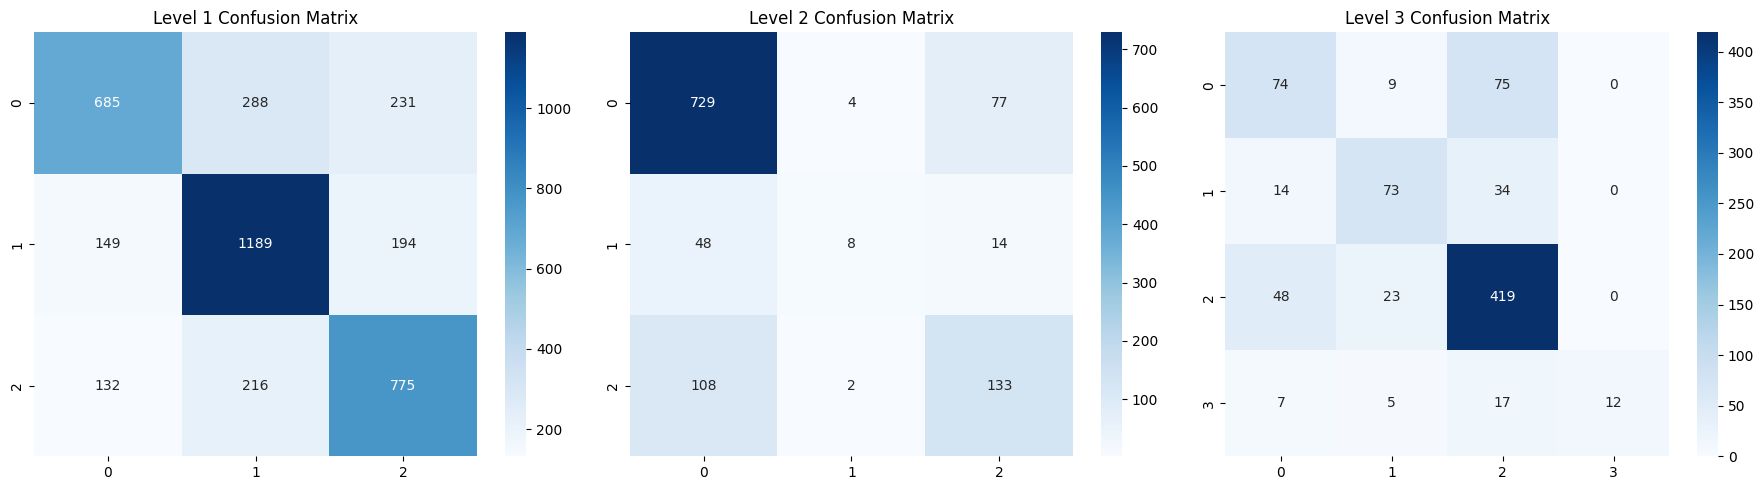

In [4]:
df = pd.read_csv("/kaggle/input/train-task1/twitter_train.csv")
df.rename(columns={
    "Tweet": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)
(y1, p1, y2, p2, y3, p3, misclassified_df,model) = train_and_evaluate(df, tokenizer)
print_results(y1, p1, y2, p2, y3, p3, misclassified_df)

In [5]:
# model1 = HierarchicalBertweet()
# model1.load_state_dict(torch.load("/kaggle/working/best_model_fold9.pt"))
# model1.cuda()
test_df = pd.read_csv("/kaggle/input/train-task1/twitter_test.csv")
test_df.rename(columns={
    "Tweet": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter

def print_classwise_accuracy(y_true, y_pred, label_names, level_name):
    cm = confusion_matrix(y_true, y_pred)
    correct_per_class = cm.diagonal()
    total_per_class = cm.sum(axis=1)
    print(f"\nClass-wise Accuracy for {level_name}:")
    for i, label in enumerate(label_names):
        acc = 100.0 * correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0.0
        print(f"  {label:<20} : {acc:.2f}% ({correct_per_class[i]}/{total_per_class[i]})")
        
def evaluate_on_test(model, test_df, tokenizer, batch_size=16):
    test_dataset = OpinionDataset(test_df['text'].tolist(),
                                   test_df['level1'].tolist(),
                                   test_df['level2'].tolist(),
                                   test_df['level3'].tolist(), tokenizer)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    model.eval()
    model.cuda()
    
    y_true1, y_pred1 = [], []
    y_true2, y_pred2 = [], []
    y_true3, y_pred3 = [], []

    label1_names = ["NOISE", "OBJECTIVE", "SUBJECTIVE"]
    label2_names = ["NEUTRAL", "NEGATIVE", "POSITIVE"]
    label3_names = ["NEUTRAL SENTIMENT", "QUESTIONS", "ADVERTISEMENTS", "MISCELLANEOUS"]
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].cuda()
            attention_mask = batch['attention_mask'].cuda()
            label1 = batch['label1']
            label2 = batch['label2']
            label3 = batch['label3']
            
            out1, out2, out3 = model(input_ids, attention_mask)
            pred1 = torch.argmax(out1, dim=1).cpu()
            pred2 = torch.argmax(out2, dim=1).cpu()
            pred3 = torch.argmax(out3, dim=1).cpu()

            y_true1.extend(label1.tolist())
            y_pred1.extend(pred1.tolist())

            for i in range(len(label1)):
                if label1[i] == 2:
                    y_true2.append(label2[i].item())
                    y_pred2.append(pred2[i].item())
                    
                    if label2[i] == 0:
                        y_true3.append(label3[i].item())
                        y_pred3.append(pred3[i].item())
    
    print("\n===== Level 1 Test Results =====")
    print("Accuracy:", accuracy_score(y_true1, y_pred1))
    print("F1 Score:", f1_score(y_true1, y_pred1, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true1, y_pred1))
    print_classwise_accuracy(y_true1, y_pred1, label1_names, "Level 1")
    
    print("\nLevel 2 Accuracy (on Level 1=2):", accuracy_score(y_true2, y_pred2))
    print("Level 2 F1 Score:", f1_score(y_true2, y_pred2, average='weighted'))
    print("Confusion Matrix - Level 2:")
    print(confusion_matrix(y_true2, y_pred2))
    print_classwise_accuracy(y_true2, y_pred2, label2_names, "Level 2")

    print("\nLevel 3 Accuracy (on Level 2=0):", accuracy_score(y_true3, y_pred3))
    print("Level 3 F1 Score:", f1_score(y_true3, y_pred3, average='weighted'))
    print("Confusion Matrix - Level 3:")
    print(confusion_matrix(y_true3, y_pred3))
    print_classwise_accuracy(y_true3, y_pred3, label3_names, "Level 3")
evaluate_on_test(model, test_df, tokenizer)


===== Level 1 Test Results =====
Accuracy: 0.682983682983683
F1 Score: 0.6808640957621398
Confusion Matrix:
 [[ 77  33  24]
 [ 16 130  24]
 [ 16  23  86]]

Class-wise Accuracy for Level 1:
  NOISE                : 57.46% (77/134)
  OBJECTIVE            : 76.47% (130/170)
  SUBJECTIVE           : 68.80% (86/125)

Level 2 Accuracy (on Level 1=2): 0.624
Level 2 F1 Score: 0.6404634628044766
Confusion Matrix - Level 2:
[[54  1 35]
 [ 1  0  7]
 [ 2  1 24]]

Class-wise Accuracy for Level 2:
  NEUTRAL              : 60.00% (54/90)
  NEGATIVE             : 0.00% (0/8)
  POSITIVE             : 88.89% (24/27)

Level 3 Accuracy (on Level 2=0): 0.6222222222222222
Level 3 F1 Score: 0.6328235845216976
Confusion Matrix - Level 3:
[[14  2  2  0]
 [ 3  9  1  0]
 [18  4 32  0]
 [ 0  2  2  1]]

Class-wise Accuracy for Level 3:
  NEUTRAL SENTIMENT    : 77.78% (14/18)
  QUESTIONS            : 69.23% (9/13)
  ADVERTISEMENTS       : 59.26% (32/54)
  MISCELLANEOUS        : 20.00% (1/5)


In [20]:
model1 = HierarchicalBertweet()
model1.load_state_dict(torch.load("/kaggle/working/best_model_fold6.pt"))
model1.cuda()
test_df = pd.read_csv("/kaggle/input/train-task1/twitter_test.csv")
test_df.rename(columns={
    "Tweet": "text",
    "Level 1": "level1",
    "Level 2": "level2",
    "Level 3": "level3"
}, inplace=True)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter

def print_classwise_accuracy(y_true, y_pred, label_names, level_name):
    cm = confusion_matrix(y_true, y_pred)
    correct_per_class = cm.diagonal()
    total_per_class = cm.sum(axis=1)
    print(f"\nClass-wise Accuracy for {level_name}:")
    for i, label in enumerate(label_names):
        acc = 100.0 * correct_per_class[i] / total_per_class[i] if total_per_class[i] > 0 else 0.0
        print(f"  {label:<20} : {acc:.2f}% ({correct_per_class[i]}/{total_per_class[i]})")
        
def evaluate_on_test(model, test_df, tokenizer, batch_size=16):
    test_dataset = OpinionDataset(test_df['text'].tolist(),
                                   test_df['level1'].tolist(),
                                   test_df['level2'].tolist(),
                                   test_df['level3'].tolist(), tokenizer)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    model.eval()
    model.cuda()
    
    y_true1, y_pred1 = [], []
    y_true2, y_pred2 = [], []
    y_true3, y_pred3 = [], []

    label1_names = ["NOISE", "OBJECTIVE", "SUBJECTIVE"]
    label2_names = ["NEUTRAL", "NEGATIVE", "POSITIVE"]
    label3_names = ["NEUTRAL SENTIMENT", "QUESTIONS", "ADVERTISEMENTS", "MISCELLANEOUS"]
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].cuda()
            attention_mask = batch['attention_mask'].cuda()
            label1 = batch['label1']
            label2 = batch['label2']
            label3 = batch['label3']
            
            out1, out2, out3 = model(input_ids, attention_mask)
            pred1 = torch.argmax(out1, dim=1).cpu()
            pred2 = torch.argmax(out2, dim=1).cpu()
            pred3 = torch.argmax(out3, dim=1).cpu()

            y_true1.extend(label1.tolist())
            y_pred1.extend(pred1.tolist())

            for i in range(len(label1)):
                if label1[i] == 2:
                    y_true2.append(label2[i].item())
                    y_pred2.append(pred2[i].item())
                    
                    if label2[i] == 0:
                        y_true3.append(label3[i].item())
                        y_pred3.append(pred3[i].item())
    
    print("\n===== Level 1 Test Results =====")
    print("Accuracy:", accuracy_score(y_true1, y_pred1))
    print("F1 Score:", f1_score(y_true1, y_pred1, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true1, y_pred1))
    print_classwise_accuracy(y_true1, y_pred1, label1_names, "Level 1")
    
    print("\nLevel 2 Accuracy (on Level 1=2):", accuracy_score(y_true2, y_pred2))
    print("Level 2 F1 Score:", f1_score(y_true2, y_pred2, average='weighted'))
    print("Confusion Matrix - Level 2:")
    print(confusion_matrix(y_true2, y_pred2))
    print_classwise_accuracy(y_true2, y_pred2, label2_names, "Level 2")

    print("\nLevel 3 Accuracy (on Level 2=0):", accuracy_score(y_true3, y_pred3))
    print("Level 3 F1 Score:", f1_score(y_true3, y_pred3, average='weighted'))
    print("Confusion Matrix - Level 3:")
    print(confusion_matrix(y_true3, y_pred3))
    print_classwise_accuracy(y_true3, y_pred3, label3_names, "Level 3")
evaluate_on_test(model1, test_df, tokenizer)


===== Level 1 Test Results =====
Accuracy: 0.7016317016317016
F1 Score: 0.6996463681443137
Confusion Matrix:
 [[ 78  27  29]
 [ 20 129  21]
 [ 11  20  94]]

Class-wise Accuracy for Level 1:
  NOISE                : 58.21% (78/134)
  OBJECTIVE            : 75.88% (129/170)
  SUBJECTIVE           : 75.20% (94/125)

Level 2 Accuracy (on Level 1=2): 0.736
Level 2 F1 Score: 0.7268631062001227
Confusion Matrix - Level 2:
[[76  0 14]
 [ 3  1  4]
 [12  0 15]]

Class-wise Accuracy for Level 2:
  NEUTRAL              : 84.44% (76/90)
  NEGATIVE             : 12.50% (1/8)
  POSITIVE             : 55.56% (15/27)

Level 3 Accuracy (on Level 2=0): 0.7888888888888889
Level 3 F1 Score: 0.7761996779388083
Confusion Matrix - Level 3:
[[12  0  6  0]
 [ 1  9  3  0]
 [ 5  0 49  0]
 [ 0  1  3  1]]

Class-wise Accuracy for Level 3:
  NEUTRAL SENTIMENT    : 66.67% (12/18)
  QUESTIONS            : 69.23% (9/13)
  ADVERTISEMENTS       : 90.74% (49/54)
  MISCELLANEOUS        : 20.00% (1/5)


In [21]:
test_df = pd.read_csv("/kaggle/input/train-task1/CRYPTO_TWITTER_TEST.csv")
texts = test_df['Text'].tolist()

class InferenceDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx],
                                  padding='max_length',
                                  truncation=True,
                                  max_length=self.max_len,
                                  return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }
        
test_dataset = InferenceDataset(texts, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16)

preds1, preds2, preds3 = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].cuda()
        attention_mask = batch['attention_mask'].cuda()

        out1, out2, out3 = model1(input_ids, attention_mask)

        p1 = torch.argmax(out1, dim=1).cpu().tolist()
        p2 = torch.argmax(out2, dim=1).cpu().tolist()
        p3 = torch.argmax(out3, dim=1).cpu().tolist()

        preds1.extend(p1)
        preds2.extend(p2)
        preds3.extend(p3)
        
test_df["Level 1"] = preds1
test_df["Level 2"] = preds2
test_df["Level 3"] = preds3

test_df[["Text","Level 1", "Level 2", "Level 3"]].to_csv("crypto_test_reddit.csv", index=False)

Predicting: 100%|██████████| 32/32 [00:01<00:00, 16.77it/s]
